FIP Project_TM

## 📊 Attendance Analytics Starter

🎯 Objective
Analyze virtual attendance logs to uncover engagement patterns and identify at-risk students.

👥 Target Audience
- Instructors
- Virtual Learning Coordinators

 🛠 Tools Used
- Python (Pandas, Matplotlib, Seaborn)
- Jupyter Notebook

In [2]:
#import necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta



In [3]:
np.random.seed(42)

In [4]:
#defining parameters
num_students = 300
num_sessions = 60

students = [f"S{str(i).zfill(3)}" for i in range(1, num_students + 1)]
sessions = [f"Session_{i}" for i in range(1, num_sessions + 1)]

start_date = datetime(2024, 1, 1)

In [5]:
# Assign engagement level to each student
student_profiles = pd.DataFrame({
    "student_id": students,
    "engagement_level": np.random.choice(
        ["high", "medium", "low"],
        size=num_students,
        p=[0.3, 0.5, 0.2]
    )
})

student_profiles.head()

,student_id,engagement_level
0,S001,medium
1,S002,low
2,S003,medium
3,S004,medium
4,S005,high


In [6]:
data = []

for session in sessions:
    
    # Realistic session scheduling
    session_day_offset = np.random.randint(0, 30)
    session_date = start_date + timedelta(days=session_day_offset)
    
    # Peak learning hours (more realistic)
    session_hour = int(np.random.choice([9, 10, 11, 13, 14, 15]))
    session_start = session_date + timedelta(hours=session_hour)
    
    for _, row in student_profiles.iterrows():
        student = row['student_id']
        engagement = row['engagement_level']
        
        # Attendance probability by engagement
        if engagement == "high":
            attends = np.random.rand() < 0.9
        elif engagement == "medium":
            attends = np.random.rand() < 0.6
        else:
            attends = np.random.rand() < 0.3
        
        if not attends:
            continue
        
        # Late join behavior
        late_minutes = np.random.randint(0, 10)
        join_time = session_start + timedelta(minutes=late_minutes)
        
        # Duration by engagement
        if engagement == "high":
            duration = np.random.randint(45, 90)
        elif engagement == "medium":
            duration = np.random.randint(20, 60)
        else:
            duration = np.random.randint(5, 25)
        
        # Early drop-off simulation
        if np.random.rand() < 0.1:
            duration = duration * np.random.uniform(0.3, 0.7)
        
        leave_time = join_time + timedelta(minutes=int(duration))
        
        data.append([
            session,
            student,
            join_time,
            leave_time,
            engagement  # keep for validation (optional)
        ])

df = pd.DataFrame(data, columns=[
    "session_id",
    "student_id",
    "joined_at",
    "left_at",
    "engagement_level"
])

df.head()

,session_id,student_id,joined_at,left_at,engagement_level
0,Session_1,S001,2024-01-13 13:02:00,2024-01-13 14:01:00,medium
1,Session_1,S003,2024-01-13 13:02:00,2024-01-13 13:38:00,medium
2,Session_1,S004,2024-01-13 13:09:00,2024-01-13 13:39:00,medium
3,Session_1,S005,2024-01-13 13:08:00,2024-01-13 14:04:00,high
4,Session_1,S006,2024-01-13 13:00:00,2024-01-13 14:18:00,high


In [7]:
# Introduce missing values (simulate real data issues)
mask = np.random.rand(len(df)) < 0.01
df.loc[mask, 'left_at'] = None

# Introduce some invalid durations
mask_invalid = np.random.rand(len(df)) < 0.01
df.loc[mask_invalid, 'left_at'] = df.loc[mask_invalid, 'joined_at'] - timedelta(minutes=5)

In [8]:
df.to_csv("attendance_logs_raw.csv", index=False)


This dataset was synthetically generated using behavior-driven logic:

### Key Features:
- Students categorized into high, medium, and low engagement
- Attendance probability varies by engagement level
- Session durations reflect real learning behavior
- Includes:
  - Late joins
  - Early exits
  - Missing values
  - Invalid records

This approach mimics real-world virtual learning environments while maintaining data privacy.

## Data Cleaning

In this step, we prepare the dataset for analysis by:
- Handling missing values
- Converting datetime columns
- Removing invalid records (e.g., negative durations)
- Creating a session duration feature

Clean data ensures accurate analysis and reliable insights.

In [9]:
#Loading data
df = pd.read_csv("attendance_logs_raw.csv")

df.head()

,session_id,student_id,joined_at,left_at,engagement_level
0,Session_1,S001,2024-01-13 13:02:00,2024-01-13 14:01:00,medium
1,Session_1,S003,2024-01-13 13:02:00,2024-01-13 13:38:00,medium
2,Session_1,S004,2024-01-13 13:09:00,2024-01-13 13:39:00,medium
3,Session_1,S005,2024-01-13 13:08:00,2024-01-13 14:04:00,high
4,Session_1,S006,2024-01-13 13:00:00,2024-01-13 14:18:00,high


In [10]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11351 entries, 0 to 11350
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   session_id        11351 non-null  object
 1   student_id        11351 non-null  object
 2   joined_at         11351 non-null  object
 3   left_at           11237 non-null  object
 4   engagement_level  11351 non-null  object
dtypes: object(5)
memory usage: 443.5+ KB


session_id            0
student_id            0
joined_at             0
left_at             114
engagement_level      0
dtype: int64

- the joined_at, left_at columns should have date datatype and not string/object

- there are 114 missing values in the left_at column

In [11]:
# correct datatype
df['joined_at'] = pd.to_datetime(df['joined_at'], errors='coerce')
df['left_at'] = pd.to_datetime(df['left_at'], errors='coerce')

In [12]:
#drop rows with missing values
df = df.dropna(subset=['left_at'])

In [13]:
#create session durations
df['session_duration'] = (
    (df['left_at'] - df['joined_at'])
    .dt.total_seconds() / 60
)

In [14]:
#remove invalid records
df = df[df['session_duration'] > 0]

In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 11123 entries, 0 to 11350
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   session_id        11123 non-null  object        
 1   student_id        11123 non-null  object        
 2   joined_at         11123 non-null  datetime64[ns]
 3   left_at           11123 non-null  datetime64[ns]
 4   engagement_level  11123 non-null  object        
 5   session_duration  11123 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 608.3+ KB


,joined_at,left_at,session_duration
count,11123,11123,11123.000000
mean,2024-01-16 10:28:32.192753664,2024-01-16 11:15:30.806437376,46.976895
min,2024-01-01 09:00:00,2024-01-01 09:06:00,1.000000
25%,2024-01-09 09:02:00,2024-01-09 09:21:00,29.000000
50%,2024-01-15 10:09:00,2024-01-15 11:27:00,48.000000
75%,2024-01-23 10:08:30,2024-01-23 11:21:30,62.000000
max,2024-01-30 15:09:00,2024-01-30 16:36:00,89.000000
std,NaN,NaN,21.527601


## Feature Engineering

In this step, we derive key metrics to measure student engagement:

### Student-Level Metrics:
- Total sessions attended
- Average session duration
- Total attendance time
- Attendance rate

### Time-Based Features:
- Day of week
- Hour of day
- Most active day per student

In [16]:
#Time features
df['day_of_week'] = df['joined_at'].dt.day_name()
df['hour'] = df['joined_at'].dt.hour

In [17]:
#total no of sessions
total_sessions = df['session_id'].nunique()
print("Total sessions:", total_sessions)

Total sessions: 60


In [18]:
#student level metrics
student_metrics = df.groupby('student_id').agg(
    total_sessions_attended=('session_id', 'nunique'),
    avg_duration=('session_duration', 'mean'),
    total_time=('session_duration', 'sum')
).reset_index()

In [19]:
#attendance rate
student_metrics['attendance_rate'] = (
    student_metrics['total_sessions_attended'] / total_sessions
)

In [20]:
#most active day
most_active_day = (
    df.groupby(['student_id', 'day_of_week'])
      .size()
      .reset_index(name='count')
)

most_active_day = most_active_day.sort_values(
    ['student_id', 'count'], ascending=[True, False]
)

most_active_day = most_active_day.drop_duplicates('student_id')

student_metrics = student_metrics.merge(
    most_active_day[['student_id', 'day_of_week']],
    on='student_id',
    how='left'
)

student_metrics.rename(columns={'day_of_week': 'most_active_day'}, inplace=True)

In [21]:
student_metrics.head()
student_metrics.describe()

,total_sessions_attended,avg_duration,total_time,attendance_rate
count,300.000000,300.000000,300.000000,300.000000
mean,37.076667,40.727716,1741.746667,0.617944
std,13.310699,18.161125,1189.213549,0.221845
min,8.000000,10.526316,89.000000,0.133333
25%,30.000000,34.625774,1119.250000,0.500000
50%,37.000000,38.208772,1376.500000,0.616667
75%,51.000000,61.569265,3223.000000,0.850000
max,57.000000,68.547170,3757.000000,0.950000


In [23]:
df.to_csv("attendance_logs_cleaned.csv", index=False) 

### Feature Engineering Summary

- Derived engagement metrics at the student level
- Calculated attendance rate to measure participation consistency
- Identified most active day for scheduling insights

These features enable deeper analysis and support predictive modeling.

## Exploratory Data Analysis (EDA)

This section explores student engagement patterns using visualizations with focus on:
- Identifying highly engaged students
- Understanding attendance trends over time
- Discovering peak engagement periods
- Analyzing session duration behavior

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

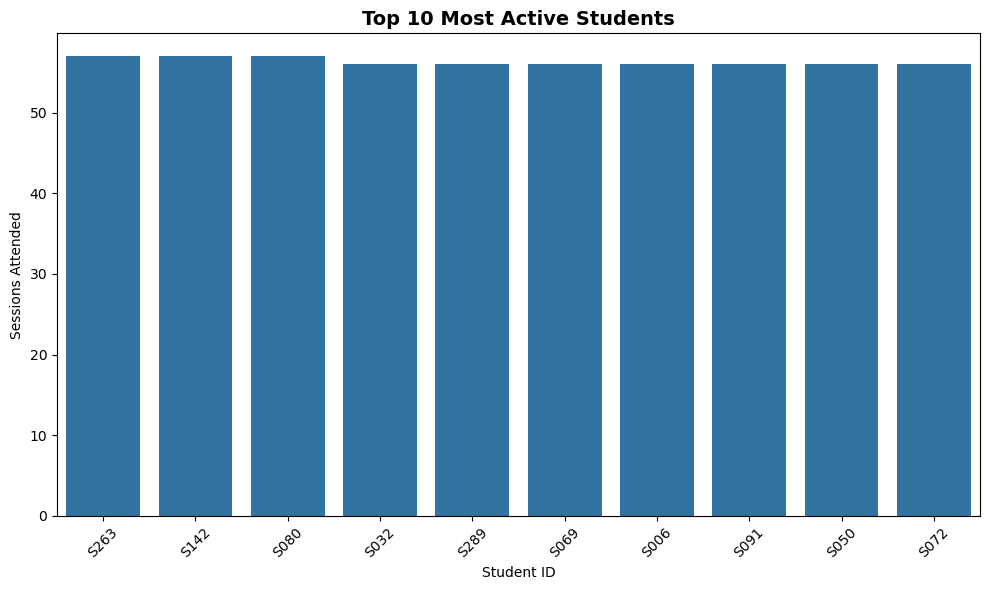

In [25]:
#top 10 most active students
top_students = (
    student_metrics
    .sort_values('total_sessions_attended', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_students,
    x='student_id',
    y='total_sessions_attended'
)

plt.title("Top 10 Most Active Students", fontsize=14, fontweight='bold')
plt.xlabel("Student ID")
plt.ylabel("Sessions Attended")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Insight: Top Active Students

- A small group of students consistently attends the highest number of sessions.
- These students may serve as benchmarks for ideal participation behavior.

 Recommendation:
- Identify what drives their engagement (timing, content, instructor style)
- Replicate these factors across sessions

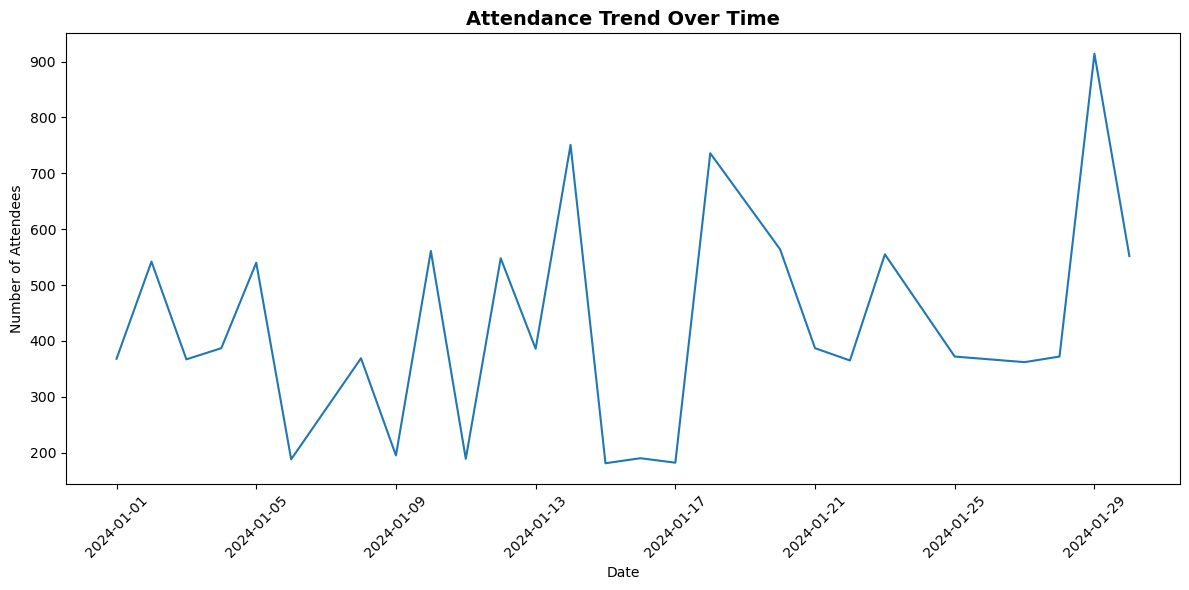

In [26]:
#attendance trend by day
daily_attendance = (
    df.groupby(df['joined_at'].dt.date)
    .size()
)

plt.figure(figsize=(12,6))
daily_attendance.plot()

plt.title("Attendance Trend Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Attendees")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Attendance Trend

- Attendance fluctuates across days, indicating varying engagement levels.
- Peaks suggest high-interest sessions or favorable timing.
- Drops may indicate scheduling conflicts or low engagement sessions.

Recommendation:
- Schedule important sessions on high-attendance days like 29th January
- Investigate causes of low-attendance periods

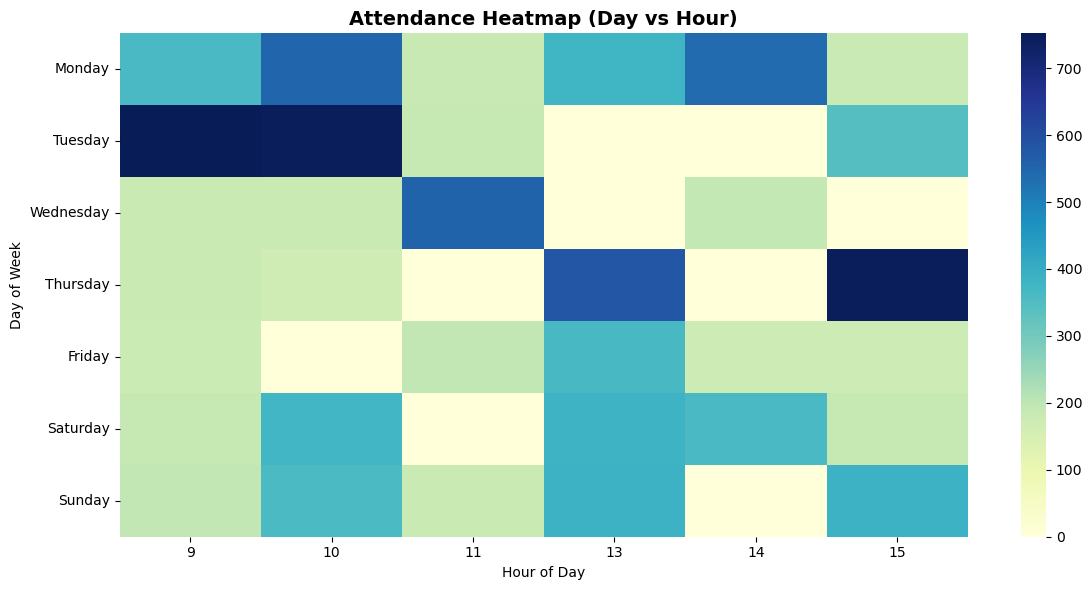

In [27]:
#day vs hour heatmap
heatmap_data = (
    df.groupby(['day_of_week', 'hour'])
    .size()
    .unstack(fill_value=0)
)

# Reorder days properly
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='YlGnBu')

plt.title("Attendance Heatmap (Day vs Hour)", fontsize=14, fontweight='bold')
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

Insight: Peak Engagement Times

- Attendance is concentrated during 9am till 3pm.
- Weekdays show higher engagement compared to weekends.
- Mid-morning to early afternoon appears to be peak participation time.

Recommendation:
- Schedule key sessions during peak hours i.e. 9am till 10am on tuesdays and 3pm on thursdays
- Avoid low-engagement time slots

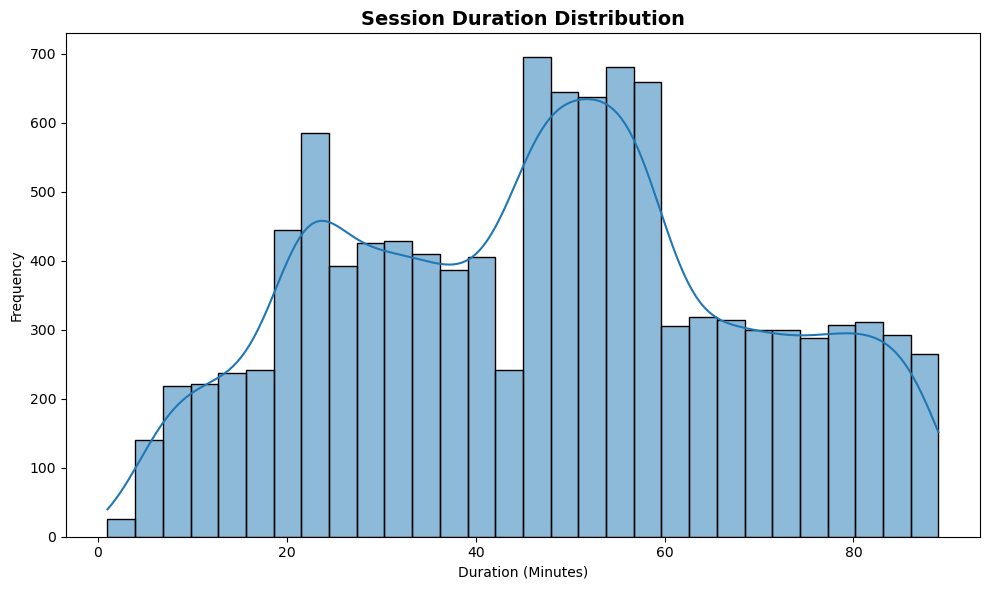

In [28]:
#session duration distribution
plt.figure(figsize=(10,6))

sns.histplot(df['session_duration'], bins=30, kde=True)

plt.title("Session Duration Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Insight: Session Duration Distribution

- Most sessions fall within a moderate duration range i.e. 40 - 60 minutes).
- A noticeable number of short sessions suggests early drop-offs.
- Very long sessions are rare, indicating realistic session lengths all below 90mins

Recommendation:
- Monitor students with consistently short durations
- Consider engagement strategies to reduce early exits

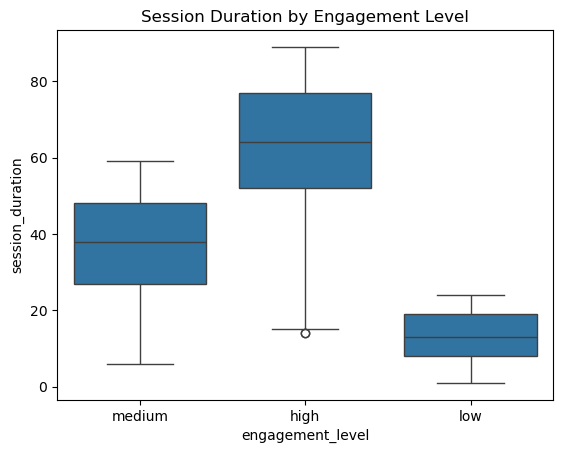

In [29]:
#engagement by level
sns.boxplot(x='engagement_level', y='session_duration', data=df)
plt.title("Session Duration by Engagement Level")
plt.show()

Insight: Session duration by engagement level

- The most engaging sessions falls within 50 - 75 minutes
- The least engaging sessions falls below 20mins

Recommendation:
- Reassess low duration sessions for a content curriculum versus intended audience fit.


🤖 At-Risk Student Predictor

To support early intervention, we define a rule-based model to identify students who may be at risk of disengagement.

A student is flagged as **at-risk** if:
- Attendance rate is below 50%, OR
- Average session duration is below 20 minutes

This provides a simple yet effective way to detect low engagement patterns.

In [30]:
#define thresholds
attendance_threshold = 0.5
duration_threshold = 20

In [31]:
#create at-risk flag
student_metrics['at_risk'] = np.where(
    (student_metrics['attendance_rate'] < attendance_threshold) |
    (student_metrics['avg_duration'] < duration_threshold),
    1, 0
)

student_metrics.head()

,student_id,total_sessions_attended,avg_duration,total_time,attendance_rate,most_active_day,at_risk
0,S001,36,36.027778,1297.0,0.600000,Monday,0
1,S002,12,11.500000,138.0,0.200000,Monday,1
2,S003,32,37.656250,1205.0,0.533333,Tuesday,0
3,S004,34,36.852941,1253.0,0.566667,Saturday,0
4,S005,54,60.907407,3289.0,0.900000,Tuesday,0


In [32]:
#distribution check
student_metrics['at_risk'].value_counts()

at_risk
0    230
1     70
Name: count, dtype: int64

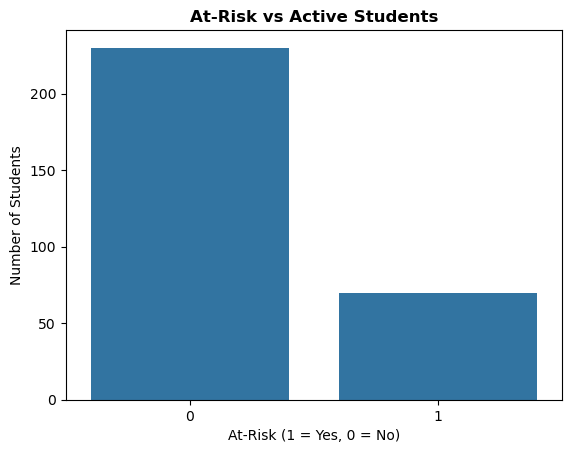

In [33]:
#visualise at-risk versus active

plt.figure()
sns.countplot(data=student_metrics, x='at_risk')

plt.title("At-Risk vs Active Students", fontweight='bold')
plt.xlabel("At-Risk (1 = Yes, 0 = No)")
plt.ylabel("Number of Students")

plt.show()

Justification for Threshold assumptions

**1. Attendance Rate < 50%**
- Indicates inconsistent participation
- Suggests the student is missing a majority of sessions

**2. Average Duration < 20 Minutes**
- Suggests low engagement even when present
- May indicate distraction, lack of interest, or technical issues

These thresholds are simple, interpretable, and aligned with real-world engagement expectations.

### 💼 Business Impact

This model enables instructors to:

- Identify disengaged students early
- Take proactive action (reminders, support, check-ins)
- Improve overall course completion rates
- Optimize teaching strategies based on engagement patterns

 Use Cases
- Weekly engagement reports
- Automated alerts for low-performing students
- Personalized learning interventions

In [34]:
def risk_reason(row):
    if row['attendance_rate'] < 0.5 and row['avg_duration'] < 20:
        return "Low Attendance & Low Duration"
    elif row['attendance_rate'] < 0.5:
        return "Low Attendance"
    elif row['avg_duration'] < 20:
        return "Low Duration"
    else:
        return "Active"

student_metrics['risk_reason'] = student_metrics.apply(risk_reason, axis=1)

student_metrics.head()

,student_id,total_sessions_attended,avg_duration,total_time,attendance_rate,most_active_day,at_risk,risk_reason
0,S001,36,36.027778,1297.0,0.600000,Monday,0,Active
1,S002,12,11.500000,138.0,0.200000,Monday,1,Low Attendance & Low Duration
2,S003,32,37.656250,1205.0,0.533333,Tuesday,0,Active
3,S004,34,36.852941,1253.0,0.566667,Saturday,0,Active
4,S005,54,60.907407,3289.0,0.900000,Tuesday,0,Active


### Model Evaluation: At-Risk Students

Even though this is a rule-based predictor, we evaluate it to understand engagement patterns:

- Distribution of at-risk vs active students
- Comparison of key metrics between groups
- Visualization for easy interpretation

In [35]:
#compare key metrics
metrics_comparison = student_metrics.groupby('at_risk')[['avg_duration','attendance_rate']].mean().reset_index()
metrics_comparison

,at_risk,avg_duration,attendance_rate
0,0,48.318315,0.714058
1,1,15.787175,0.302143


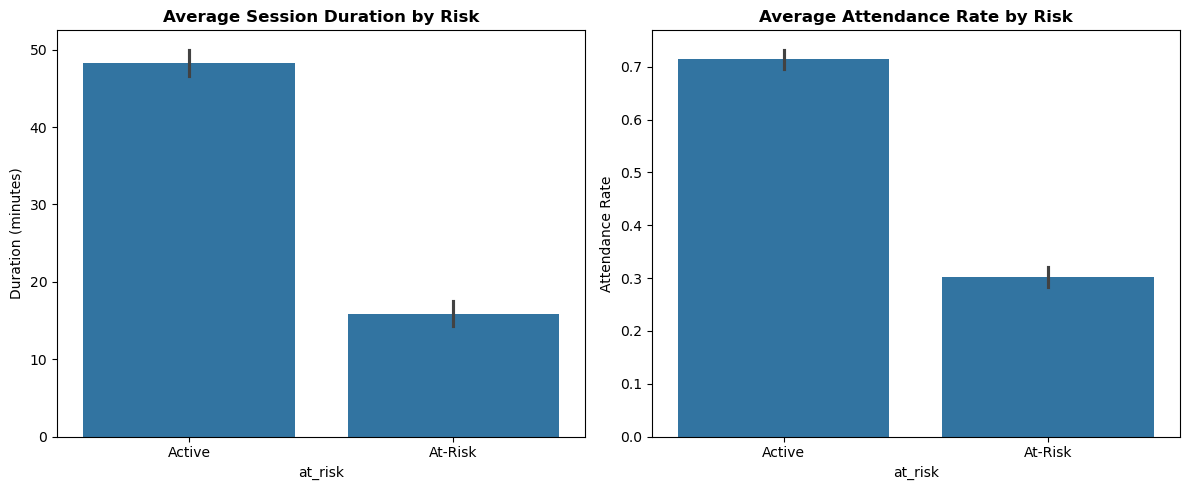

In [36]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Avg Duration
sns.barplot(x='at_risk', y='avg_duration', data=student_metrics, ax=axes[0])
axes[0].set_title("Average Session Duration by Risk", fontweight='bold')
axes[0].set_xticks([0, 1]) 
axes[0].set_xticklabels(['Active', 'At-Risk'])
axes[0].set_ylabel("Duration (minutes)")

# Attendance Rate
sns.barplot(x='at_risk', y='attendance_rate', data=student_metrics, ax=axes[1])
axes[1].set_title("Average Attendance Rate by Risk", fontweight='bold')
axes[1].set_xticks([0, 1]) 
axes[1].set_xticklabels(['Active', 'At-Risk'])
axes[1].set_ylabel("Attendance Rate")

plt.tight_layout()
plt.show()

### 🔹 Insights from Model Evaluation

1. **Distribution**: The majority of students are active, but a significant portion of about 30% is at-risk.
2. **Session Duration**: At-risk students have much lower average session duration below 20mins than active students.
3. **Attendance Rate**: At-risk students also attend fewer sessions, confirming low engagement.
4. **Actionable Insight**: These metrics validate the rule-based thresholds and highlight the students who need early intervention.

Recommendation:
- Focus support on the at-risk group to improve engagement and retention.
- Monitor both attendance and duration to detect subtle disengagement patterns.

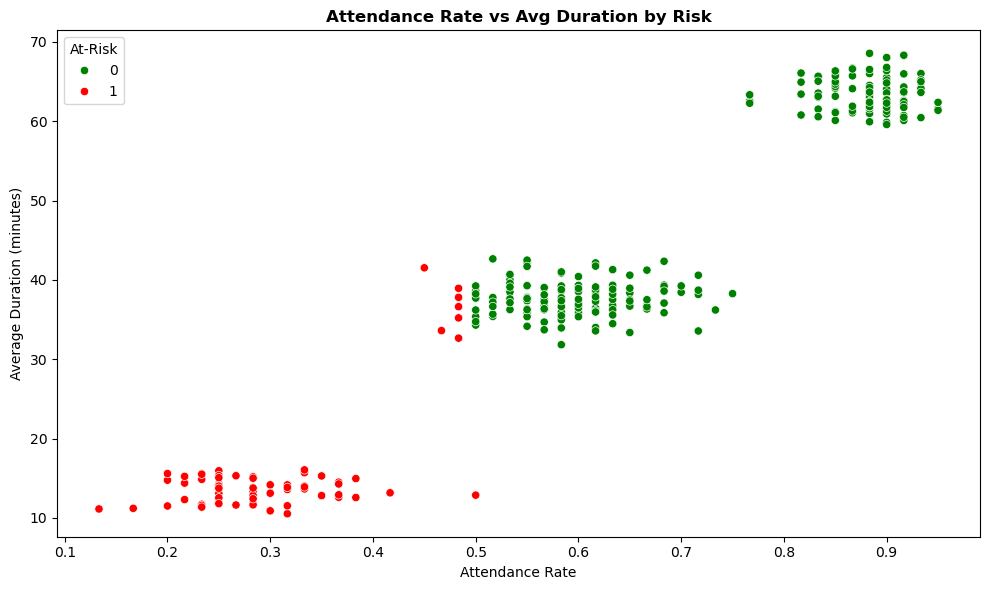

In [37]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='attendance_rate',
    y='avg_duration',
    hue='at_risk',
    data=student_metrics,
    palette={0:'green',1:'red'}
)
plt.title("Attendance Rate vs Avg Duration by Risk", fontweight='bold')
plt.xlabel("Attendance Rate")
plt.ylabel("Average Duration (minutes)")
plt.legend(title='At-Risk')
plt.tight_layout()
plt.show()

## Final Insights & Recommendations

Key Findings

1. **Engagement is uneven across students**
   - A small group of students accounts for a large portion of total attendance.
   - This indicates a gap between highly engaged and disengaged learners.

2. **Attendance varies by day and time**
   - Certain days and hours show significantly higher participation.
   - Peak engagement occurs during mid-morning to early afternoon sessions.

3. **Session duration is a strong engagement indicator**
   - Most engaged students stay for 40–60 minutes.
   - Short session durations (<20 mins) are common among disengaged students.

4. **A significant portion of students are at risk**
   - The rule-based model identified a meaningful number of students with low attendance or short session duration.
   - These students are likely to drop off without intervention.

5. **Attendance rate and duration together provide strong signals**
   - Students with both low attendance and low duration consistently show disengagement patterns.

Recommendations for Instructors

1. **Prioritize early intervention**
   - Reach out to at-risk students weekly
   - Provide reminders, support, or personalized follow-ups

2. **Optimize session scheduling**
   - Schedule key sessions during peak engagement hours
   - Avoid low-attendance periods identified in the analysis

3. **Improve session engagement strategies**
   - Incorporate interactive elements (polls, Q&A, breakout rooms)
   - Keep sessions concise and engaging to reduce early drop-offs

4. **Monitor engagement continuously**
   - Track attendance rate and session duration as core KPIs
   - Use dashboards or alerts to flag declining participation

5. **Leverage high-performing students**
   - Identify highly engaged students
   - Encourage peer learning or mentorship opportunities